# Overview
- Count
- Temporal distribution
- Geographical distribution
- Wind distribution

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, select_nearest_swot_coloc

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# DATA

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

____
# Count colocation points
## All 250m and 2km

In [3]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]

DS = dataset_coloc_combs(comb_list, nearest =False)


df250 = DS.isel(id_comb=0).to_dataframe().dropna()
df2 = DS.isel(id_comb=1).to_dataframe().dropna()
len(df250), len(df2)

nofilter__swot250naive_etaf__rio_15era5
nofilter__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


(381831, 307621)

In [4]:
df2.drifter_type.unique()

array(['CARTHE', 'SVP', 'MELODI', 'SPOTTER', 'SVPOGS', 'SVPSIO', 'SVPBGC',
       'CODE', 'SVP-B', 'HEREON'], dtype=object)

In [5]:
df2.depth.unique()

array([  0.,  15., 100.,  50.])

In [6]:
df250.groupby('drifter_type').longitude.count(), df2.groupby('drifter_type').longitude.count()

(drifter_type
 CARTHE     135782
 CODE         5471
 HEREON      47617
 MELODI      11752
 SPOTTER      1757
 SVP        112268
 SVP-B       24710
 SVPBGC        596
 SVPOGS       7737
 SVPSIO      34141
 Name: longitude, dtype: int64,
 drifter_type
 CARTHE     109520
 CODE         4308
 HEREON      38676
 MELODI       9931
 SPOTTER      1078
 SVP         85999
 SVP-B       21179
 SVPBGC        596
 SVPOGS       6425
 SVPSIO      29909
 Name: longitude, dtype: int64)

In [8]:
df250.groupby('depth').longitude.count(), df2.groupby('depth').longitude.count()

(depth
 0.0      202379
 15.0     160443
 50.0      10005
 100.0      9004
 Name: longitude, dtype: int64,
 depth
 0.0      163513
 15.0     129319
 50.0       7089
 100.0      7700
 Name: longitude, dtype: int64)

In [9]:
df250n = select_nearest_swot_coloc(df250)
df2n = select_nearest_swot_coloc(df2)
len(df250n), len(df2n)

(2978, 2539)

In [10]:
df250n.groupby('drifter_type').longitude.count(), df2n.groupby('drifter_type').longitude.count()

(drifter_type
 CARTHE     1060
 CODE         53
 HEREON      355
 MELODI      128
 SPOTTER      17
 SVP         869
 SVP-B       167
 SVPBGC        6
 SVPOGS       72
 SVPSIO      251
 Name: longitude, dtype: int64,
 drifter_type
 CARTHE     925
 CODE        45
 HEREON     299
 MELODI     119
 SPOTTER     11
 SVP        698
 SVP-B      149
 SVPBGC       6
 SVPOGS      64
 SVPSIO     223
 Name: longitude, dtype: int64)

In [11]:
df250n.groupby('depth').longitude.count(), df2n.groupby('depth').longitude.count()

(depth
 0.0      1613
 15.0     1215
 50.0       82
 100.0      68
 Name: longitude, dtype: int64,
 depth
 0.0      1399
 15.0     1024
 50.0       57
 100.0      59
 Name: longitude, dtype: int64)

In [12]:
df250n.groupby('drifter_type').longitude.count(), df2n.groupby('drifter_type').longitude.count()

(drifter_type
 CARTHE     1060
 CODE         53
 HEREON      355
 MELODI      128
 SPOTTER      17
 SVP         869
 SVP-B       167
 SVPBGC        6
 SVPOGS       72
 SVPSIO      251
 Name: longitude, dtype: int64,
 drifter_type
 CARTHE     925
 CODE        45
 HEREON     299
 MELODI     119
 SPOTTER     11
 SVP        698
 SVP-B      149
 SVPBGC       6
 SVPOGS      64
 SVPSIO     223
 Name: longitude, dtype: int64)

_______
# Add other info on coloc


In [13]:
var_to_add = ['cycle_date', 'acceleration_north','w10_era5', 'iss_era5', 'inss', 'iews', 'v10','u10']


# 250m
dic = comb_list[0]
dfd = pd.read_csv(DRIFTER[dic['drifter_key']],parse_dates=['datetime', 'cycle_date']).set_index('row_number')
dfalti = pd.read_csv(ALTI[dic['alti_key']]).set_index('row_number').drop(columns=['longitude', 'latitude'])
dfwd = pd.read_csv(WD[dic['wd_key']]).set_index('row_number').drop(columns=['longitude', 'latitude'])
df = pd.concat([dfd, dfalti, dfwd], axis=1, verify_integrity=True)
df['iss_era5'] = np.sqrt(df.inss**2 + df.iews**2)
df['w10_era5'] = np.sqrt(df.u10**2 + df.v10**2)
df250 = pd.concat([df250, df[var_to_add]], axis=1)

# 250m
dic = comb_list[1]
dfd = pd.read_csv(DRIFTER[dic['drifter_key']],parse_dates=['datetime', 'cycle_date'] ).set_index('row_number')
dfalti = pd.read_csv(ALTI[dic['alti_key']]).set_index('row_number').drop(columns=['longitude', 'latitude'])
dfwd = pd.read_csv(WD[dic['wd_key']]).set_index('row_number').drop(columns=['longitude', 'latitude'])
df = pd.concat([dfd, dfalti, dfwd], axis=1, verify_integrity=True)
df['iss_era5'] = np.sqrt(df.inss**2 + df.iews**2)
df['w10_era5'] = np.sqrt(df.u10**2 + df.v10**2)
df2 = pd.concat([df2, df[var_to_add]], axis=1)


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_57540/2483624349.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfd = pd.read_csv(DRIFTER[dic['drifter_key']],parse_dates=['datetime', 'cycle_date']).set_index('row_number')
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_57540/2483624349.py:16: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfd = pd.read_csv(DRIFTER[dic['drifter_key']],parse_dates=['datetime', 'cycle_date'] ).set_index('row_number')


In [21]:
df250n = select_nearest_swot_coloc(df250)
df2n = select_nearest_swot_coloc(df2)

____
# Temporal distribution

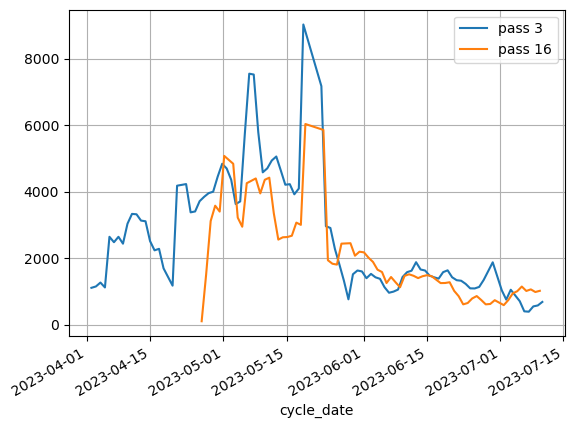

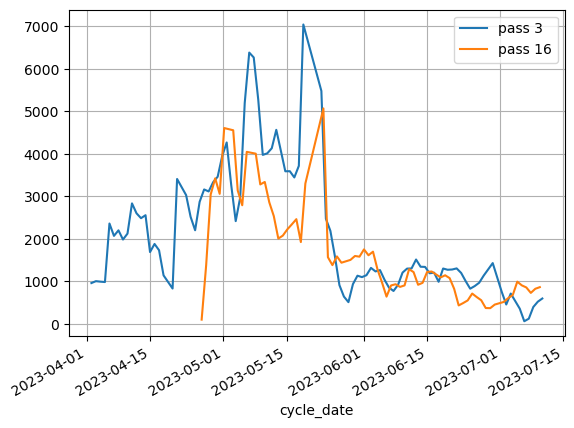

In [14]:
for df in [df250, df2] :
    fig, axs = plt.subplots(1,1, sharex=True)
    df[df.pass_number==3].groupby(['cycle_date']).acceleration_north.count().plot(ax=axs, label = 'pass 3')
    df[df.pass_number==16].groupby(['cycle_date']).acceleration_north.count().plot(ax=axs, label = 'pass 16')
    axs.grid()
    axs.legend()
    #fig.tight_layout()

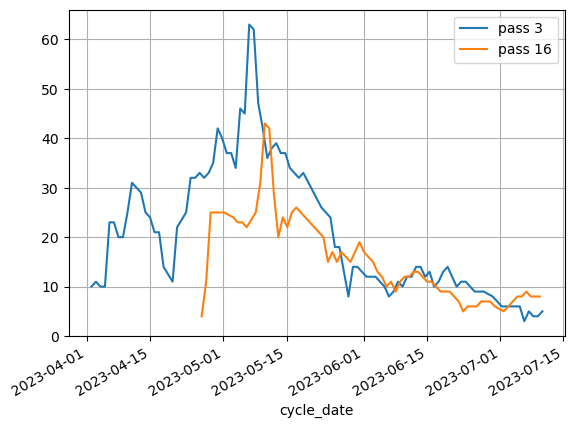

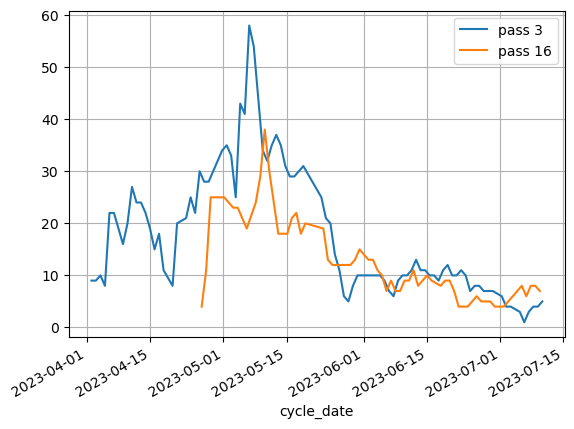

In [23]:
for dfc in [df250n, df2n] :
    fig, axs = plt.subplots(1,1, sharex=True)
    dfc[dfc.pass_number==3].groupby(['cycle_date']).acceleration_north.count().plot(ax=axs, label = 'pass 3')
    dfc[dfc.pass_number==16].groupby(['cycle_date']).acceleration_north.count().plot(ax=axs, label = 'pass 16')
    axs.grid()
    axs.legend()
    #fig.tight_layout()

____
# Geographical distribution

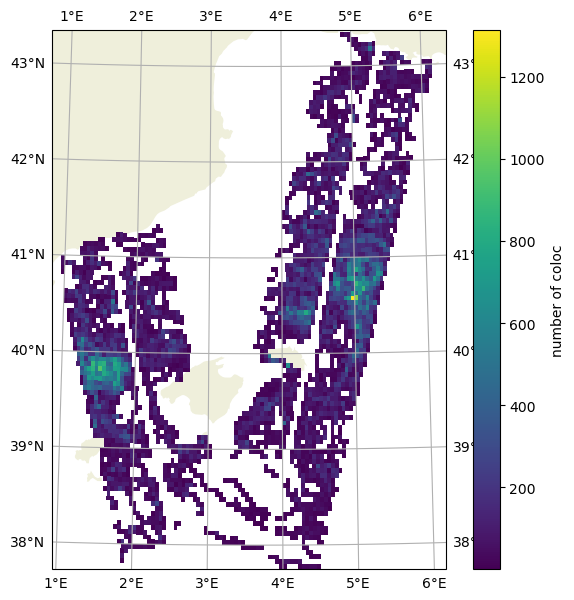

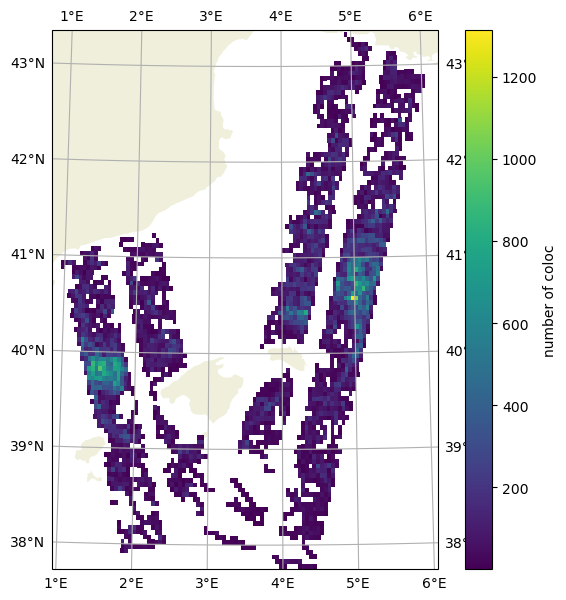

In [24]:
for df in [df250, df2]:

    dl = 0.5/10
    df["latbin"] = (df.latitude // dl) * dl
    df["lonbin"] = (df.longitude // dl) * dl
    dd = df.groupby(["latbin", "lonbin"]).acceleration_north.count().to_xarray()
    dd.name = 'number of coloc'
    dd['lonbin'] = dd['lonbin']+dl/2
    dd['latbin'] = dd['latbin']+dl/2
    
    
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    ax.add_feature(cfeature.LAND,)
    dd.plot(ax=ax, transform=crs)
    gl = ax.gridlines(draw_labels=True,)

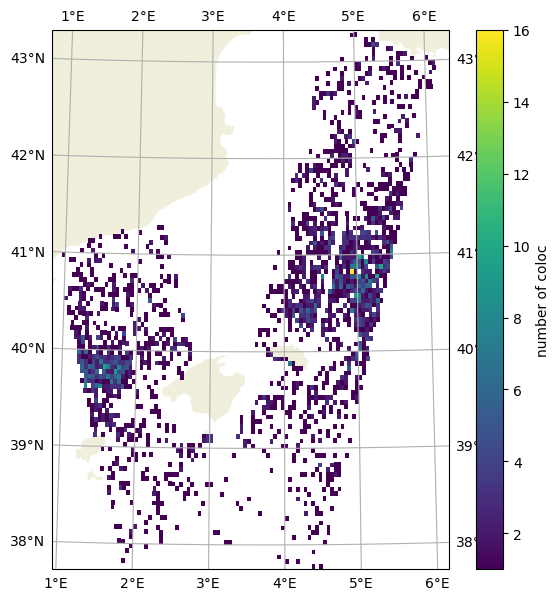

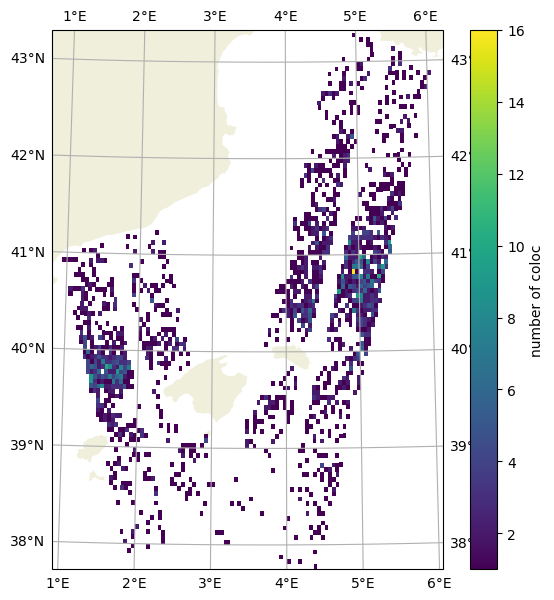

In [25]:
for dfc in [df250n, df2n]:
    dl = 0.5/10
    dfc["latbin"] = (dfc.latitude // dl) * dl
    dfc["lonbin"] = (dfc.longitude // dl) * dl
    dd = dfc.groupby(["latbin", "lonbin"]).acceleration_north.count().to_xarray()
    dd.name = 'number of coloc'
    dd['lonbin'] = dd['lonbin']+dl/2
    dd['latbin'] = dd['latbin']+dl/2
    
    
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    ax.add_feature(cfeature.LAND,)
    dd.plot(ax=ax, transform=crs)
    gl = ax.gridlines(draw_labels=True,)

____
# Geographical distribution

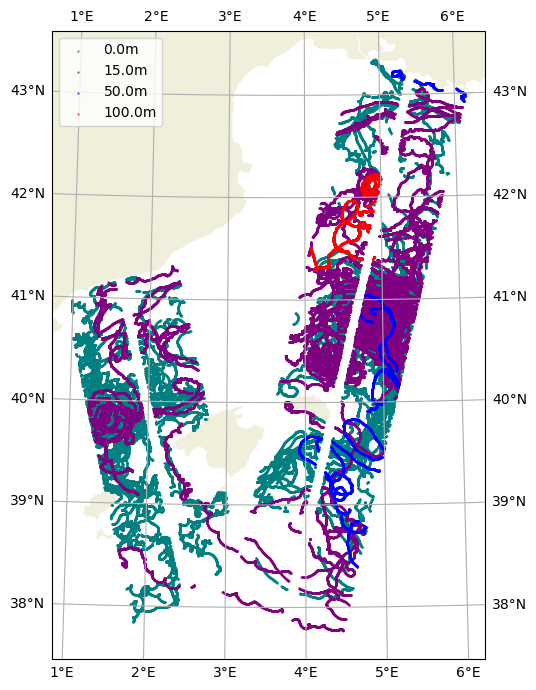

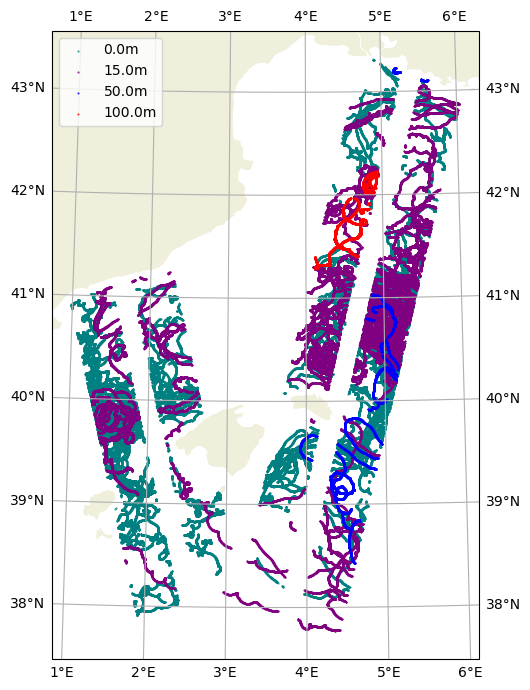

In [26]:
depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'} 

for df in [df250, df2]:
    depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'} # inverser couleur
    #bbox = [2.7, 6.1, 36.6, 43.4]
    fig = plt.figure(figsize=(7,7), frameon=False)
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    for d in sorted(df.depth.dropna().unique()) : 
        df[df.depth == d].plot.scatter('longitude', 'latitude', ax=ax, transform =crs, color = depthcolor[d], s = 0.2, label = f'{d}m')
    #ax.set_extent(bbox)
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'geographical_distribution.png'), dpi=200, bbox_inches='tight')


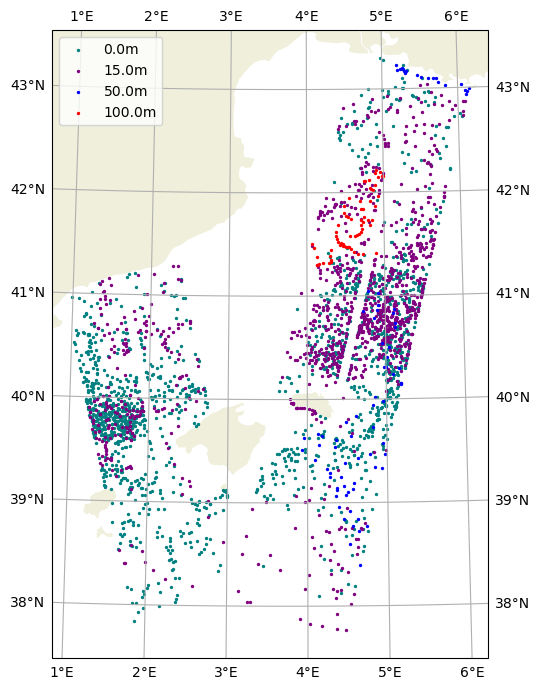

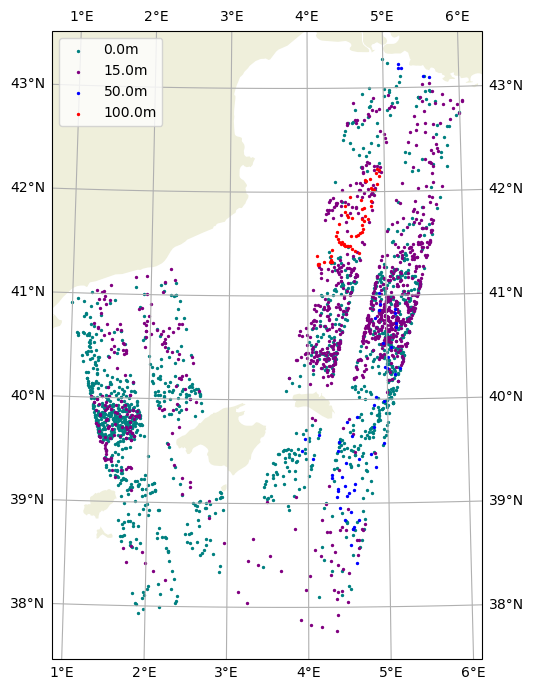

In [27]:
for dfc in [df250n, df2n]:
    depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'} # inverser couleur
    #bbox = [2.7, 6.1, 36.6, 43.4]
    fig = plt.figure(figsize=(7,7), frameon=False)
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    for d in sorted(df.depth.dropna().unique()) : 
        dfc[dfc.depth == d].plot.scatter('longitude', 'latitude', ax=ax, transform =crs, color = depthcolor[d], s = 2, label = f'{d}m')
    #ax.set_extent(bbox)
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'geographical_distribution.png'), dpi=200, bbox_inches='tight')


In [28]:
df.depth.unique()

array([  0.,  15., 100.,  50.,  nan])

____
# WIND CONDITIONS

In [ ]:
for df in [df250, df2]:
    
    depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'}
    #bbox = [2.7, 6.1, 36.6, 43.4]
    fig = plt.figure(figsize=(12,7), frameon=False)
    
    ax = fig.add_subplot(121)
    # This is the colormap I'd like to use.
    cm = plt.colormaps.get_cmap('viridis')
    # Get the histogram
    Y,X = np.histogram(df.w10_era5, bins = 30)
    x_span = X.max()-X.min()
    C = [cm(((x-X.min())/x_span)) for x in X]
    ax.bar(X[:-1],Y,color=C,width=X[1]-X[0])
    ax.grid()
    ax.set_xlabel(r'ERA5 Wind at 10m [$m.s^{-1}$]')
    
    ax = fig.add_subplot(122, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    #a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
    a = ax.scatter(df.longitude, df.latitude, c=df.w10_era5, transform =crs, s=df.iss_era5*20)
    #ax.set_extent(bbox)
    ax.add_feature(cfeature.LAND,)
    
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False
    
    cb = plt.colorbar(a)
    cb.set_label(r'ERA5 Wind at 10m [$m.s^{-1}$]')
    
    #cbar = fig.colorbar(a, ax=ax)
    #cbar.set_label('a')
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'geographical_distribution_wd.png'), dpi=200, bbox_inches='tight')


In [ ]:
for dfc in [df250n, df2n]:
    depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'}
    #bbox = [2.7, 6.1, 36.6, 43.4]
    fig = plt.figure(figsize=(12,7), frameon=False)
    
    ax = fig.add_subplot(121)
    # This is the colormap I'd like to use.
    cm = plt.colormaps.get_cmap('viridis')
    # Get the histogram
    Y,X = np.histogram(dfc.w10_era5, bins = 30)
    x_span = X.max()-X.min()
    C = [cm(((x-X.min())/x_span)) for x in X]
    ax.bar(X[:-1],Y,color=C,width=X[1]-X[0])
    ax.grid()
    ax.set_xlabel(r'ERA5 Wind at 10m [$m.s^{-1}$]')
    
    ax = fig.add_subplot(122, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    #a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
    a = ax.scatter(dfc.longitude, dfc.latitude, c=dfc.w10_era5, transform =crs, s=2)
    #ax.set_extent(bbox)
    ax.add_feature(cfeature.LAND,)
    
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False
    
    cb = plt.colorbar(a)
    cb.set_label(r'ERA5 Wind at 10m [$m.s^{-1}$]')
    
    #cbar = fig.colorbar(a, ax=ax)
    #cbar.set_label('a')
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'geographical_distribution_wd.png'), dpi=200, bbox_inches='tight')


In [ ]:
depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'}
#bbox = [2.7, 6.1, 36.6, 43.4]
fig = plt.figure(figsize=(12,7), frameon=False)

ax = fig.add_subplot(121)
# This is the colormap I'd like to use.
cm = plt.colormaps.get_cmap('viridis')
# Get the histogram
Y,X = np.histogram(dfc.w10_era5, bins = 30)
x_span = X.max()-X.min()
C = [cm(((x-X.min())/x_span)) for x in X]
ax.bar(X[:-1],Y,color=C,width=X[1]-X[0])
ax.grid()
ax.set_xlabel(r'ERA5 surface stress [$N.m^{-2}$]')

ax = fig.add_subplot(122, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
#a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
a = ax.scatter(dfc.longitude, dfc.latitude, c=dfc.w10_era5, s=dfc.iss_era5*20, transform =crs)
#ax.set_extent(bbox)
ax.add_feature(cfeature.LAND,)

gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False

cb = plt.colorbar(a)
cb.set_label(r'ERA5 Wind at 10m [$m.s^{-1}$]')

#cbar = fig.colorbar(a, ax=ax)
#cbar.set_label('a')
fig.tight_layout()
fig.savefig(os.path.join(images_dir, 'geographical_distribution_wd.png'), dpi=200, bbox_inches='tight')


In [ ]:
for df in [df250, df2] : 
    fig, axs = plt.subplots(1,1, sharex=True)
    df[df.pass_number==3].groupby('cycle_date').w10_era5.mean().plot(ax=axs, label = 'pass 3')
    df[df.pass_number==16].groupby('cycle_date').w10_era5.mean().plot(ax=axs, label = 'pass 16')
    axs.grid()
    axs.legend()
    axs.set_ylabel(r'ERA5 Wind at 10m [$m.s^{-1}$]')